In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.nonparametric.smoothers_lowess import lowess
import time
import warnings
warnings.filterwarnings('ignore')

In [15]:
# ── 字体配置 ──────────────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False
 
# ── 配置区 ────────────────────────────────────────────────────────────────────
N_BINS = 500
FRAC   = 0.15
 
# ── 1. 读取数据 ───────────────────────────────────────────────────────────────
t0 = time.time()
class_data = rf'e'

all_desc_parquet = rf'F:\04.Data_v2\caominghao_v4\{class_data}13.descriptive_stat'
if class_data == 'c':
    filenamel = rf'desc_data_poseffectMale'
elif class_data == 'd':
    filenamel = rf'desc_data_negaeffectMale'
elif class_data == 'e':
    filenamel = rf'desc_data_poseffectFemale'
elif class_data == 'f':
    filenamel = rf'desc_data_negaeffectFemale'
yj_desc_data_wide = (
    pl.scan_parquet(
        rf'{all_desc_parquet}/{filenamel}_chrom_*_or_wide.parquet'
    )
    .select(['median_P', 'median_M', 'lnIQRR', 'lnMR', 'iqr_P', 'iqr_M', 'lnQCDR'])
    .collect()
    .to_pandas()
)
print(f"[{time.time()-t0:.1f}s] 数据读取完成，维度: {yj_desc_data_wide.shape}")
 
df = yj_desc_data_wide.dropna(subset=['median_P', 'median_M', 'lnIQRR', 'lnMR',
                                       'iqr_P', 'iqr_M', 'lnQCDR'])

[0.0s] 数据读取完成，维度: (269654, 7)


In [16]:
# ── 2. 分位数分组取均值 ───────────────────────────────────────────────────────
def bin_mean(df, x_col, y_col, n_bins=500):
    x = df[x_col].values
    y = df[y_col].values
    order = np.argsort(x)
    x_s, y_s = x[order], y[order]
    idx_splits = np.array_split(np.arange(len(x_s)), n_bins)
    return (
        np.array([x_s[i].mean() for i in idx_splits]),
        np.array([y_s[i].mean() for i in idx_splits])
    )
 
t1 = time.time()
x_A,  y_A  = bin_mean(df, 'median_P', 'median_M', N_BINS)
x_BP, y_BP = bin_mean(df, 'median_P', 'lnIQRR',   N_BINS)
x_BM, y_BM = bin_mean(df, 'median_M', 'lnIQRR',   N_BINS)
x_CP, y_CP = bin_mean(df, 'median_P', 'iqr_P',    N_BINS)
x_CM, y_CM = bin_mean(df, 'median_M', 'iqr_M',    N_BINS)
x_DP, y_DP = bin_mean(df, 'median_P', 'lnQCDR',   N_BINS)
x_DM, y_DM = bin_mean(df, 'median_M', 'lnQCDR',   N_BINS)
print(f"[{time.time()-t1:.1f}s] 分位数分组完成")
 
# ── 3. LOESS 拟合 ─────────────────────────────────────────────────────────────
t2 = time.time()
loess_A  = lowess(y_A,  x_A,  frac=FRAC, return_sorted=True)
loess_BP = lowess(y_BP, x_BP, frac=FRAC, return_sorted=True)
loess_BM = lowess(y_BM, x_BM, frac=FRAC, return_sorted=True)
loess_CP = lowess(y_CP, x_CP, frac=FRAC, return_sorted=True)
loess_CM = lowess(y_CM, x_CM, frac=FRAC, return_sorted=True)
loess_DP = lowess(y_DP, x_DP, frac=FRAC, return_sorted=True)
loess_DM = lowess(y_DM, x_DM, frac=FRAC, return_sorted=True)
print(f"[{time.time()-t2:.1f}s] LOESS 拟合完成")
 

[0.1s] 分位数分组完成
[0.1s] LOESS 拟合完成


绘图散点采样量: 269 条（占总数据 1%）


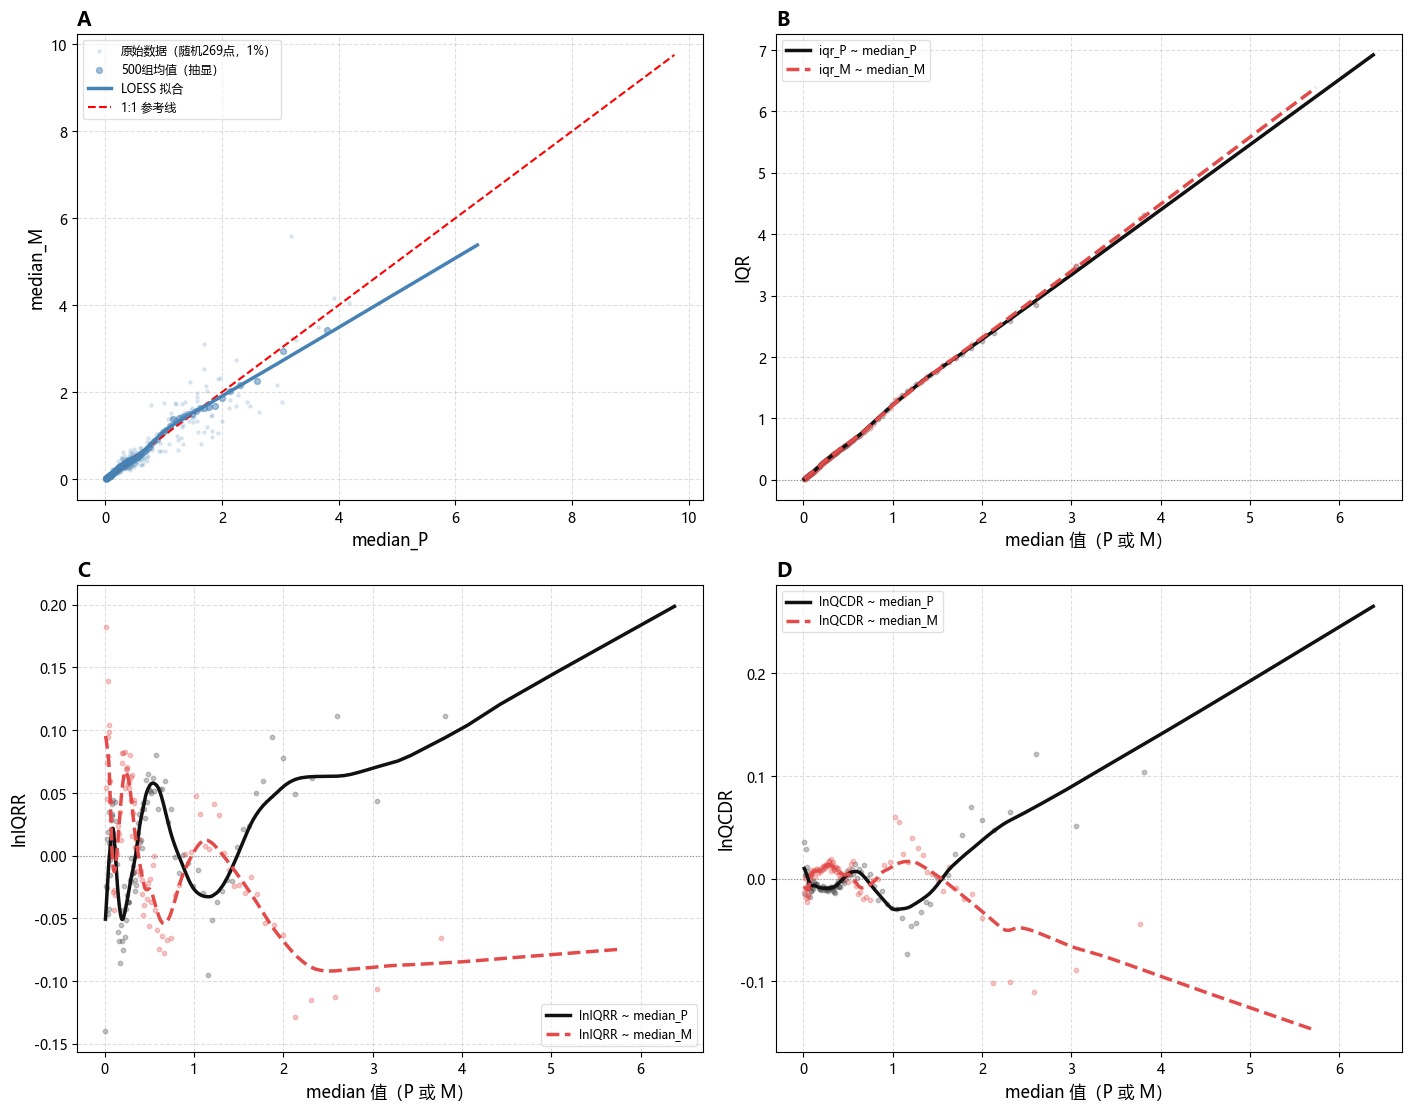

[1.0s] 绘图完成
总耗时: 1.4s


In [17]:
# ── 4. 绘图（2×2，ABCD）──────────────────────────────────────────────────────
t3 = time.time()
fig = plt.figure(figsize=(14, 11), constrained_layout=True)
gs  = gridspec.GridSpec(2, 2, figure=fig)
 
rng = np.random.default_rng(42)
 
# ── 散点采样：仅用1%数据绘图，计算部分不受影响 ───────────────────────────────
n_plot     = int(len(df) * 0.001)          # 1% 采样量
sample_idx = rng.choice(len(df), size=n_plot, replace=False)

print(f"绘图散点采样量: {n_plot:,} 条（占总数据 1%）")
 
# 均值点也做1%采样显示（500点 → 约5点，太少；改为固定显示100个均值点）
bin_step   = max(1, N_BINS // 100)        # 每隔 bin_step 取一个均值点显示
ALPHA_SC   = 0.15
S_SC       = 5

# ━━ 图A：gs[0,0] — LOESS median_P → median_M + 1:1 参考线 ━━━━━━━━━━━━━━━━━━
ax_a = fig.add_subplot(gs[0, 0])
 
lim_min = min(df['median_P'].min(), df['median_M'].min())
lim_max = max(df['median_P'].max(), df['median_M'].max())
 
ax_a.scatter(
    df['median_P'].values[sample_idx], df['median_M'].values[sample_idx],
    color='steelblue', alpha=ALPHA_SC, s=S_SC, zorder=1,
    label=f'原始数据（随机{n_plot:,}点，1%）'
)
ax_a.scatter(
    x_A[::bin_step], y_A[::bin_step],
    color='steelblue', s=18, alpha=0.5, zorder=2, label=f'{N_BINS}组均值（抽显）'
)
ax_a.plot(loess_A[:, 0], loess_A[:, 1],
          color='steelblue', lw=2.5, zorder=5, label='LOESS 拟合')
ax_a.plot([lim_min, lim_max], [lim_min, lim_max],
          color='red', lw=1.5, linestyle='--', zorder=4, label='1:1 参考线')
 
ax_a.set_xlabel('median_P', fontsize=12)
ax_a.set_ylabel('median_M', fontsize=12)
ax_a.set_title('A', fontsize=14, fontweight='bold', loc='left')
ax_a.legend(fontsize=8.5, framealpha=0.6)
ax_a.grid(True, linestyle='--', alpha=0.4)
ax_a.tick_params(labelsize=10)
 
# ━━ 图B：gs[0,1] — IQR LOESS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax_b = fig.add_subplot(gs[0, 1])
 
ax_b.scatter(
    x_CP[::bin_step], y_CP[::bin_step],
    color='#444444', s=10, alpha=0.3, zorder=2
)
ax_b.scatter(
    x_CM[::bin_step], y_CM[::bin_step],
    color='#E24B4A', s=10, alpha=0.3, zorder=2
)
ax_b.plot(loess_CP[:, 0], loess_CP[:, 1],
          color='#111111', lw=2.5, zorder=5, label='iqr_P ~ median_P')
ax_b.plot(loess_CM[:, 0], loess_CM[:, 1],
          color='#E24B4A', lw=2.5, zorder=5, linestyle='--',
          label='iqr_M ~ median_M')
ax_b.axhline(0, color='gray', lw=0.8, linestyle=':', zorder=1)
 
ax_b.set_xlabel('median 值（P 或 M）', fontsize=12)
ax_b.set_ylabel('IQR', fontsize=12)
ax_b.set_title('B', fontsize=14, fontweight='bold', loc='left')
ax_b.legend(fontsize=8.5, framealpha=0.6)
ax_b.grid(True, linestyle='--', alpha=0.4)
ax_b.tick_params(labelsize=10)
 
# ━━ 图C：gs[1,0] — lnIQRR LOESS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax_c = fig.add_subplot(gs[1, 0])
 
ax_c.scatter(
    x_BP[::bin_step], y_BP[::bin_step],
    color='#444444', s=10, alpha=0.3, zorder=2
)
ax_c.scatter(
    x_BM[::bin_step], y_BM[::bin_step],
    color='#E24B4A', s=10, alpha=0.3, zorder=2
)
ax_c.plot(loess_BP[:, 0], loess_BP[:, 1],
          color='#111111', lw=2.5, zorder=5, label='lnIQRR ~ median_P')
ax_c.plot(loess_BM[:, 0], loess_BM[:, 1],
          color='#E24B4A', lw=2.5, zorder=5, linestyle='--',
          label='lnIQRR ~ median_M')
ax_c.axhline(0, color='gray', lw=0.8, linestyle=':', zorder=1)
 
ax_c.set_xlabel('median 值（P 或 M）', fontsize=12)
ax_c.set_ylabel('lnIQRR', fontsize=12)
ax_c.set_title('C', fontsize=14, fontweight='bold', loc='left')
ax_c.legend(fontsize=8.5, framealpha=0.6)
ax_c.grid(True, linestyle='--', alpha=0.4)
ax_c.tick_params(labelsize=10)
 
# ━━ 图D：gs[1,1] — lnQCDR LOESS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax_d = fig.add_subplot(gs[1, 1])
 
ax_d.scatter(
    x_DP[::bin_step], y_DP[::bin_step],
    color='#444444', s=10, alpha=0.3, zorder=2
)
ax_d.scatter(
    x_DM[::bin_step], y_DM[::bin_step],
    color='#E24B4A', s=10, alpha=0.3, zorder=2
)
ax_d.plot(loess_DP[:, 0], loess_DP[:, 1],
          color='#111111', lw=2.5, zorder=5, label='lnQCDR ~ median_P')
ax_d.plot(loess_DM[:, 0], loess_DM[:, 1],
          color='#E24B4A', lw=2.5, zorder=5, linestyle='--',
          label='lnQCDR ~ median_M')
ax_d.axhline(0, color='gray', lw=0.8, linestyle=':', zorder=1)
 
ax_d.set_xlabel('median 值（P 或 M）', fontsize=12)
ax_d.set_ylabel('lnQCDR', fontsize=12)
ax_d.set_title('D', fontsize=14, fontweight='bold', loc='left')
ax_d.legend(fontsize=8.5, framealpha=0.6)
ax_d.grid(True, linestyle='--', alpha=0.4)
ax_d.tick_params(labelsize=10)
 
# ── 总标题 & 输出 ─────────────────────────────────────────────────────────────
#fig.suptitle(f'median_P 与 median_M 的系统性差异分析（LOESS：IQR / lnIQRR / lnQCDR）', fontsize=13)
#plt.savefig('plot_ABCD_v3.png', dpi=180, bbox_inches='tight')
plot_path_1 = rf"D:\02.File\2025-2026学年第2学期\02.文章\v2026.4.11\01.代码直出\2026.4.13.{class_data}_median_lnIQRR.pdf"
plt.savefig(plot_path_1,format='pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f"[{time.time()-t3:.1f}s] 绘图完成")
print(f"总耗时: {time.time()-t0:.1f}s")